# Run scMODAL for the integration of tonsil datasets

In this tutorial, we apply scMODAL to the integration of tonsil CODEX, scRNA-seq and scATAC-seq datasets. The raw datasets are available at https://datadryad.org/stash/share/1OQtxew0Unh3iAdP-ELew-ctwuPTBz6Oy8uuyxqliZk, https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE165860 and https://zenodo.org/records/11355186. Preprocessed data can be found here: https://drive.google.com/drive/folders/1-8Di5xv5hXqG68rOj4jAhBWEznt5oVnR?usp=sharing, where ATAC data were transfered to the gene activity matrix using Signac.

## Import packages

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import commot as ct
import os

import scmodal

import warnings
warnings.filterwarnings("ignore")

## Preprocessing

### Load data

In [2]:
adata_CODEX = ad.read_h5ad('./data/tonsil/adata_codex.h5ad')
adata_RNA = ad.read_h5ad('./data/tonsil/adata_rna.h5ad')
adata_ATAC = ad.read_h5ad('./data/tonsil/adata_atac.h5ad')

### Identify shared and unique features

In [3]:
correspondence = pd.read_csv('./protein_gene_conversion.csv', )
correspondence['Protein name'] = correspondence['Protein name'].replace(to_replace={'CD11a-CD18': 'CD11a/CD18', 'CD66a-c-e': 'CD66a/c/e'})

In [4]:
rna_protein_correspondence = []

for i in range(correspondence.shape[0]):
    curr_protein_name, curr_rna_names = correspondence.iloc[i]
    if curr_protein_name not in adata_CODEX.var_names:
        continue
    if curr_rna_names.find('Ignore') != -1: # some correspondence ignored eg. protein isoform to one gene
        continue
    curr_rna_names = curr_rna_names.split('/') # eg. one protein to multiple genes
    for r in curr_rna_names:
        if r in adata_RNA.var_names:
            rna_protein_correspondence.append([r, curr_protein_name])
            
rna_protein_correspondence = np.array(rna_protein_correspondence)

In [5]:
adata_RNA_shared = adata_RNA[:, rna_protein_correspondence[:, 0]].copy()
adata_CODEX_shared = adata_CODEX[:, rna_protein_correspondence[:, 1]].copy()

adata_RNA_shared.var_names_make_unique()
adata_CODEX_shared.var_names_make_unique()

In [6]:
df_cellchat = ct.pp.ligand_receptor_database(species='human', signaling_type='Secreted Signaling', database='CellPhoneDB_v4.0')
print(df_cellchat.shape)

(1447, 4)


In [7]:
# Preserve more genes in ligand-receptor database in scRNA-seq data for cell-cell communication inference

adata_RNA_unshared = adata_RNA[:, sorted(set(adata_RNA.var.index) - set(rna_protein_correspondence[:, 0]))].copy()
adata_RNA_lr = adata_RNA_unshared[:, adata_RNA_unshared.var.index.isin(np.unique(df_cellchat['0'].values)) | adata_RNA_unshared.var.index.isin(np.unique(df_cellchat['1'].values))].copy()
adata_RNA_lr_variable = adata_RNA_lr[:, (np.sum(adata_RNA_lr.X.toarray(), axis=0) > 10)].var.index

sc.pp.highly_variable_genes(adata_RNA_unshared, flavor='seurat_v3', n_top_genes=1000)
adata_RNA_unshared = adata_RNA_unshared[:, adata_RNA_unshared.var.highly_variable | adata_RNA_unshared.var.index.isin(adata_RNA_lr_variable)].copy()

In [8]:
# Finding ATAC / CODEX shared features is helpful for normalizing ATAC data

atac_protein_correspondence = []

for i in range(correspondence.shape[0]):
    curr_protein_name, curr_rna_names = correspondence.iloc[i]
    if curr_protein_name not in adata_CODEX.var_names:
        continue
    if curr_rna_names.find('Ignore') != -1: # some correspondence ignored eg. protein isoform to one gene
        continue
    curr_rna_names = curr_rna_names.split('/') # eg. one protein to multiple genes
    for r in curr_rna_names:
        if r in adata_ATAC.var_names:
            atac_protein_correspondence.append([r, curr_protein_name])
            
atac_protein_correspondence = np.array(atac_protein_correspondence)

In [9]:
adata_ATAC_shared = adata_ATAC[:, atac_protein_correspondence[:, 0]].copy()
adata_CODEX_ATAC_shared = adata_CODEX[:, atac_protein_correspondence[:, 1]].copy()

adata_ATAC_shared.var_names_make_unique()
adata_CODEX_ATAC_shared.var_names_make_unique()

In [10]:
adata_ATAC_unshared = adata_ATAC[:, sorted(set(adata_ATAC.var.index) - set(atac_protein_correspondence[:, 0]))].copy()
sc.pp.highly_variable_genes(adata_ATAC_unshared, flavor='seurat_v3', n_top_genes=1000)
adata_ATAC_unshared = adata_ATAC_unshared[:, adata_ATAC_unshared.var.highly_variable].copy()

### Normalization

In [11]:
sc.pp.normalize_total(adata_RNA_shared, target_sum=np.median((np.exp(adata_CODEX_shared.X)-1).sum(axis=1)))
sc.pp.log1p(adata_RNA_shared)

sc.pp.normalize_total(adata_RNA_unshared)
sc.pp.log1p(adata_RNA_unshared)

adata_RNA = ad.concat([adata_RNA_shared, adata_RNA_unshared], axis=1)
adata_RNA.obs["celltype"] = adata_RNA_shared.obs["celltype"]

adata_CODEX = adata_CODEX_shared # CODEX data do not contain unlinked features with RNA data
adata_CODEX.obs["celltype"] = adata_CODEX.obs["celltype"]

sc.pp.scale(adata_RNA, max_value=10)
sc.pp.scale(adata_CODEX, max_value=10)

sc.pp.normalize_total(adata_ATAC_shared, target_sum=np.median((np.exp(adata_CODEX_ATAC_shared.X)-1).sum(axis=1)))
sc.pp.log1p(adata_ATAC_shared)

sc.pp.normalize_total(adata_ATAC_unshared)
sc.pp.log1p(adata_ATAC_unshared)

adata_ATAC = ad.concat([adata_ATAC_shared, adata_ATAC_unshared], axis=1)
adata_ATAC.obs["dataset"] = "ATAC"
adata_ATAC.obs["celltype"] = adata_ATAC_shared.obs["celltype"]

sc.pp.scale(adata_ATAC, max_value=10)

RNA_ATAC_shared = sorted(list(adata_RNA.var.index & adata_ATAC.var.index))

adata_CODEX.obs['modality'] = 'CODEX'
adata_RNA.obs['modality'] = 'RNA'
adata_ATAC.obs['modality'] = 'ATAC'
adata_RNA_ATAC_shared = ad.concat([adata_RNA[:, RNA_ATAC_shared], adata_ATAC[:, RNA_ATAC_shared]])
sc.tl.pca(adata_RNA_ATAC_shared, n_comps=30)

## Running scMODAL

In [12]:
model = scmodal.model.Model(training_steps=10000, lambdaMNN=5, lambdaGAN=0.5, model_path="./tonsil_tutorial")
model.integrate_datasets_feats(input_feats=[adata_CODEX.X, adata_RNA.X, adata_ATAC.X], 
                              paired_input_MNN=[[adata_CODEX.X[:, :adata_RNA_shared.shape[1]], adata_RNA.X[:, :adata_RNA_shared.shape[1]]], 
                                                [adata_RNA_ATAC_shared.obsm['X_pca'][:adata_RNA.shape[0]], adata_RNA_ATAC_shared.obsm['X_pca'][adata_RNA.shape[0]:]], ])

Begining time:  Mon Apr 28 21:07:28 2025
step 0, loss_D=0.896587, loss_GAN=-0.473515, loss_AE=276.851959, loss_Geo=-11.990168, loss_LA=10724.443359, loss_MNN=371.120636
step 2000, loss_D=2.224448, loss_GAN=-2.179823, loss_AE=15.710739, loss_Geo=-29.124660, loss_LA=0.176542, loss_MNN=0.530770
step 6000, loss_D=2.559398, loss_GAN=-2.521484, loss_AE=14.851513, loss_Geo=-29.160221, loss_LA=0.121875, loss_MNN=0.404307
step 8000, loss_D=2.610829, loss_GAN=-2.585304, loss_AE=14.858552, loss_Geo=-29.035725, loss_LA=0.094044, loss_MNN=0.401230
Ending time:  Mon Apr 28 21:30:23 2025
Training takes 1374.56 seconds
Begining time:  Mon Apr 28 21:30:23 2025
Ending time:  Mon Apr 28 21:30:23 2025
Evaluating takes -0.00 seconds


In [13]:
adata_integrated = ad.AnnData(X=model.latent)
adata_integrated.obs['modality'] = ['CODEX'] * adata_CODEX.shape[0] + ['RNA'] * adata_RNA.shape[0] + ['ATAC'] * adata_ATAC.shape[0]
adata_integrated.obs['celltype'] = list(adata_CODEX.obs['celltype'].values) + list(adata_RNA.obs['celltype'].values) + list(adata_ATAC.obs['celltype'].values)

scmodal.utils.compute_umap(adata_integrated)

UMAP(angular_rp_forest=True, local_connectivity=1, metric='correlation', min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Mon Apr 28 21:30:23 2025 Construct fuzzy simplicial set
Mon Apr 28 21:30:23 2025 Finding Nearest Neighbors
Mon Apr 28 21:30:23 2025 Building RP forest with 21 trees
Mon Apr 28 21:30:26 2025 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	Stopping threshold met -- exiting after 4 iterations
Mon Apr 28 21:32:23 2025 Finished Nearest Neighbor Search
Mon Apr 28 21:32:26 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr 28 21:34:25 2025 Finished embedding


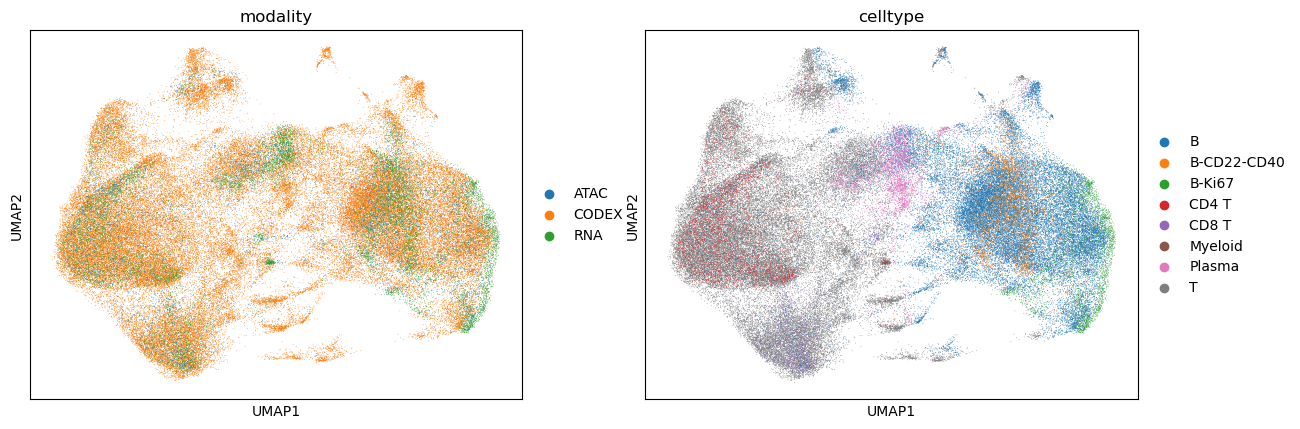

In [14]:
sc.pl.umap(adata_integrated, color=['modality', "celltype"])

## Label transfer from scRNA-seq to CODEX

In [15]:
from scipy.spatial.distance import cdist

dist_mtx = cdist(model.latent[:adata_CODEX.shape[0], :], 
                model.latent[adata_CODEX.shape[0]:(adata_RNA.shape[0]+adata_CODEX.shape[0]), :], 
                 metric='euclidean')

matching_all = dist_mtx.argsort()
matching = dist_mtx.argsort()[:, :1]

In [16]:
from scipy import stats
n = 1
result = stats.mode(adata_RNA.obs["celltype"].values.astype(str)[matching_all[:, :n]], axis=1)

transfered = result[0].reshape(-1)

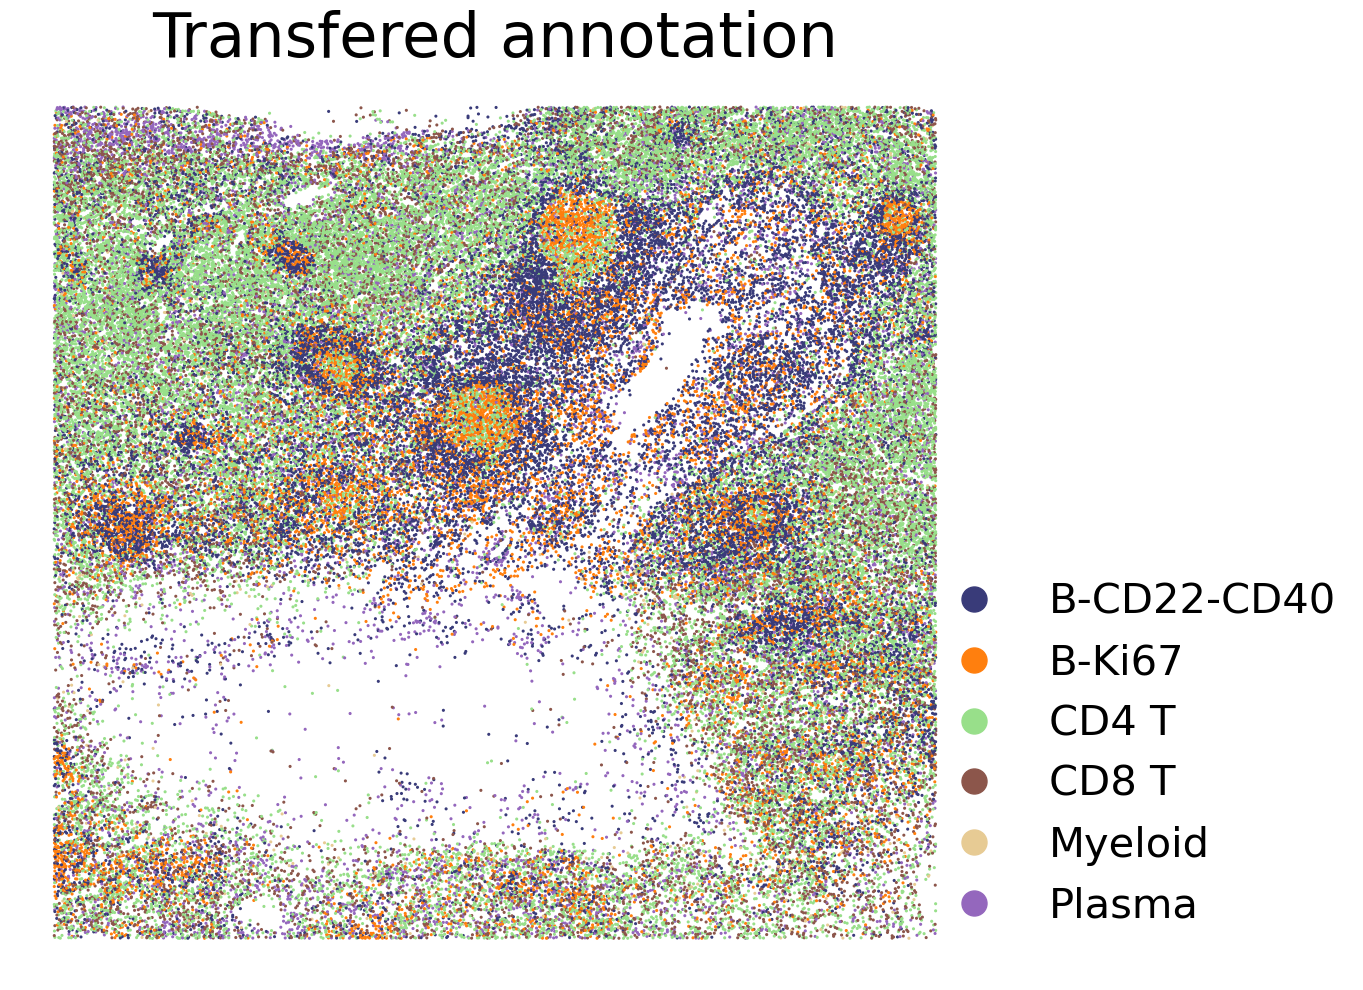

In [17]:
from sklearn import preprocessing

colours = ListedColormap(['#393b79', '#ff7f0e', '#98df8a', '#8c564b', '#e7cb94', "tab:purple"])

le = preprocessing.LabelEncoder()
le.fit(sorted(set(transfered)))
label = le.fit_transform(transfered)

f = plt.figure(figsize=(10,10))
ax1 = f.add_subplot(1,1,1)
scatter1 = ax1.scatter(adata_CODEX.obsm['spatial'][:, 0], adata_CODEX.obsm['spatial'][:, 1], c=label, cmap=colours, label=transfered, s = 1.5, rasterized=True)
ax1.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)

l1 = f.legend(handles=scatter1.legend_elements()[0], labels=sorted(set(transfered)), loc="upper left", bbox_to_anchor=(0.9, 0.45), 
                    markerscale=3., title_fontsize=30, fontsize=30, frameon=False, ncol=1)
l1._legend_box.align = "left"
ax1.set_title("Transfered annotation", fontsize=45)

f.tight_layout()
ax1.axis('off')
plt.show()